In [9]:
#Importing the python libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [5]:
cleaned_customer_transaction_data = pd.read_csv(r'/Users/Dell/Frudulent-transaction-detection-for-Finlora-Company/Finlora_Dataset/Artifacts/cleaned_cleaned_data.csv')

In [11]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1,
    palette="pastel"
)

What These Charts Tell Us 

1. (EDA)Fraud Distribution Chart (Class Imbalance): This shows the balance between real transactions and fraud. Because fraud is rare, our data is highly imbalanced. This is a warning sign: if we do not fix it, our machine learning model will just guess "legitimate" every time to look accurate. This chart helps us decide if we need to use special tools, like class weighting or resampling, to force the model to look closer at the fraud cases.

2. Transaction Channel Chart: This shows how people make transactions (like mobile, online, or ATM). It tells us which channels are the most popular and helps us spot if certain channels are more prone to fraudulent behaviour. These observations can also guide subsequent feature analysis and model development. 

In [12]:
cleaned_customer_transaction_data.columns

Index(['Unnamed: 0', 'transaction_id', 'customer_id', 'timestamp',
       'home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'device_id', 'new_device', 'ip_address', 'ip_country',
       'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

In [13]:
from matplotlib import pyplot as plt
import seaborn as sns

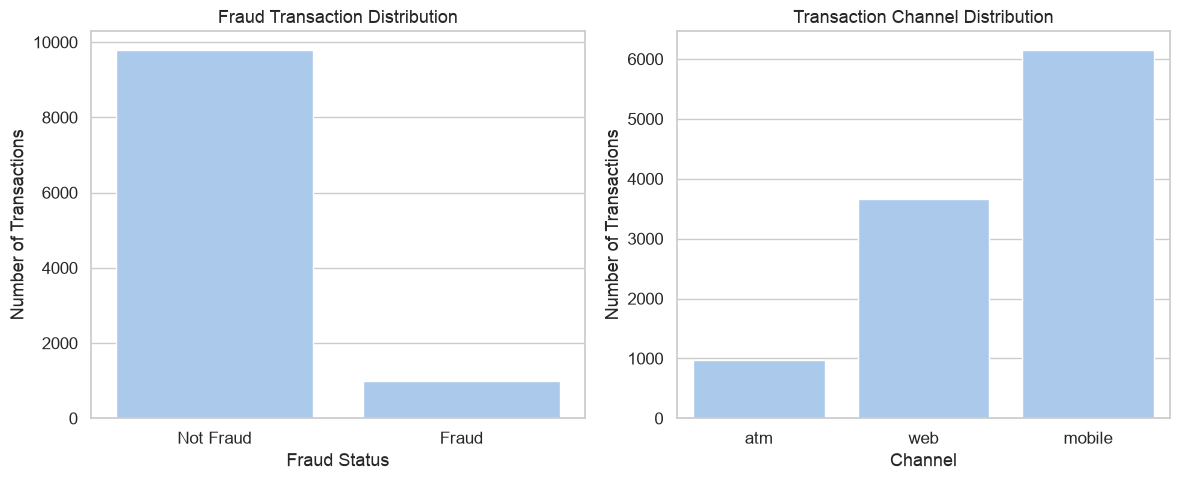

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fraud distribution
sns.countplot(data=cleaned_customer_transaction_data, x='is_fraud', ax=axes[0])
axes [0].set_title('Fraud Transaction Distribution')
axes [0].set_xlabel('Fraud Status')
axes [0].set_ylabel('Number of Transactions')
axes [0].set_xticks ([0, 1])
axes [0].set_xticklabels(['Not Fraud','Fraud'])

#Channel distribution
sns.countplot(data=cleaned_customer_transaction_data, x='channel', ax=axes[1])
axes[1].set_title('Transaction Channel Distribution')
axes [1].set_xlabel('Channel')
axes [1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

IP Country and KYC Tier Analysis

1. IP Country Distribution (Where Transactions Start):This chart shows which countries generate the most traffic and highlights underrepresented regions. By comparing IP Country vs. Fraud, we can see if fraud is concentrated in specific geographic pockets. This helps the model map out high-risk locations, though we must keep in mind that total transaction volumes vary heavily by country.

2. KYC Tier Distribution (Customer Verification Levels):This chart shows how our customer base is split across different identity verification levels. By comparing KYC Tier vs. Fraud, we look for a direct link between lower verification tiers and higher fraud rates. This confirms whether a user's security status provides strong predictive power for our model.

Main Takeaway: Combined, these visualisations reveal hidden patterns between a customer's verification level, where they are located, and fraudulent behaviour. These insights directly guide our feature engineering and machine learning model development.

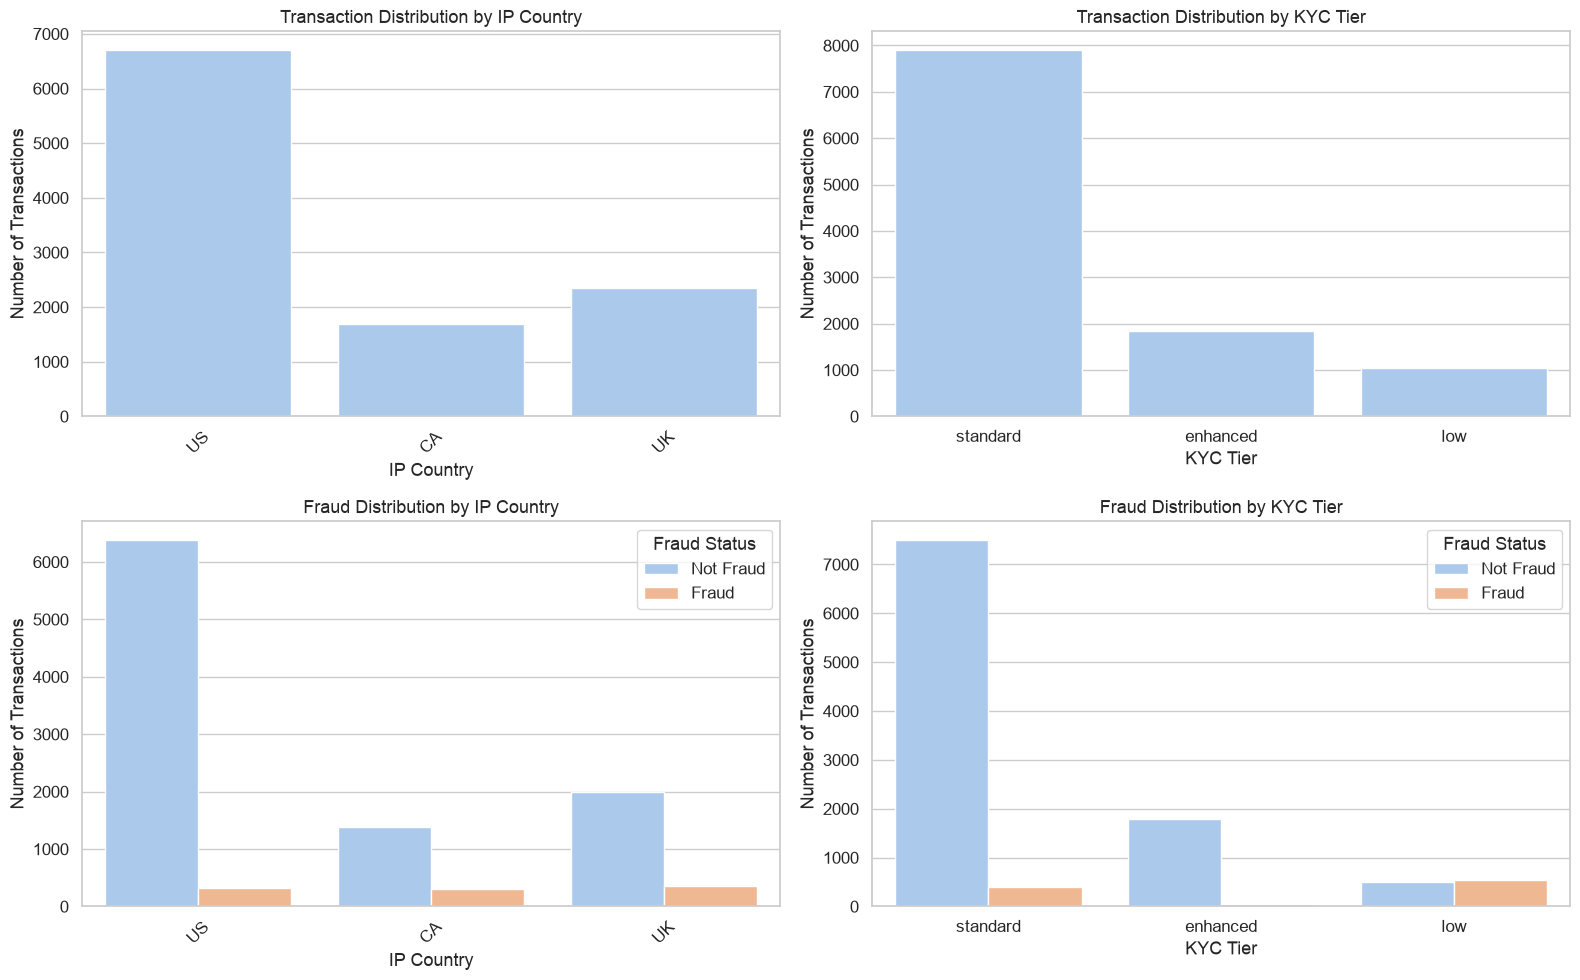

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. IP Country distribution
sns.countplot(
    data=cleaned_customer_transaction_data, 
    x='ip_country',
    ax=axes[0, 0]
)

axes[0, 0].set_title('Transaction Distribution by IP Country')
axes[0, 0].set_xlabel('IP Country')
axes[0, 0].set_ylabel('Number of Transactions')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. KYC Tier distribution
sns.countplot(
    data=cleaned_customer_transaction_data, x='kyc_tier',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Transaction Distribution by KYC Tier')
axes[0, 1].set_xlabel('KYC Tier')
axes[0, 1].set_ylabel('Number of Transactions')

# 3. IP Country vs Fraud
sns.countplot(
    data=cleaned_customer_transaction_data, 
    x='ip_country', 
    hue="is_fraud",
    ax=axes[1, 0]
)
axes[1, 0].set_title('Fraud Distribution by IP Country')
axes[1, 0].set_xlabel('IP Country')
axes [1, 0].set_ylabel('Number of Transactions') 
axes [1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])

# 4. KYC Tier vs Fraud
sns.countplot(
    data=cleaned_customer_transaction_data, x='kyc_tier',
    hue='is_fraud',
    ax=axes [1, 1]
)
axes [1, 1].set_title('Fraud Distribution by KYC Tier')
axes [1, 1].set_xlabel('KYC Tier')
axes [1, 1].set_ylabel('Number of Transactions')
axes [1, 1].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

Fraud Rate Analysis by Location Mismatch, KYC Tier, and Transaction Channel

The visualisations show how fraudulent transaction behaviour varies across location mismatch, KYC verification level, and transaction channel. The location mismatch analysis indicates a substantial difference in fraud risk depending on whether a transaction occurs in an expected location. Transactions where location_mismatch = False, meaning the transaction location is consistent with the user's expected or previously observed location, have al relatively low fraud rate of approximately 3-5%. In contrast, transactions where location_mismatch indicating an unexpected or unfamiliar transaction location, have a considerably higher fraud rate of over 35%. Based on the observed rates, transactions with a location mismatch are approximately 7-9 times more likely to be fraudulent than transactions without a location mismatch. This suggests that location mismatch may be an important predictive feature for identifying potentially fraudulent transactions.

The analysis of KYC tier also shows differences in fraud risk across customer verification levels. The results indicate that customers with lower levels of KYC verification have higher fraud rates, while customers with enhanced verification have the lowest observed fraud risk. This suggests that the level of customer verification may provide useful information for distinguishing between legitimate and potentially fraudulent transactions.

The transaction channel analysis provides two complementary perspectives. The fraud-rate chart measures the proportion of transactions that are fraudulent within each channel, while the fraud-count chart measures the actual number of fraudulent and non-fraudulent transactions. The results indicate that web transactions have a higher fraud rate than mobile transactions, suggesting that the web channel may present a relatively higher fraud risk.
However, fraud counts should be interpreted alongside fraud rates because differences in the total number of transactions across channels can influence the absolute number of fraudulent transactions.

Overall, these findings indicate that location mismatch, KYC verification level, and transaction channel may contain meaningful signals for fraud detection. These variables should therefore be considered during feature engineering and model development, while their predictive importance should ultimately be validated using statistical analysis and machine learning model evaluation.

/var/folders/13/c_bqr3w50896v5pg8y3p6zg80000gn/T/ipykernel_9316/3120330361.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/13/c_bqr3w50896v5pg8y3p6zg80000gn/T/ipykernel_9316/3120330361.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/13/c_bqr3w50896v5pg8y3p6zg80000gn/T/ipykernel_9316/3120330361.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


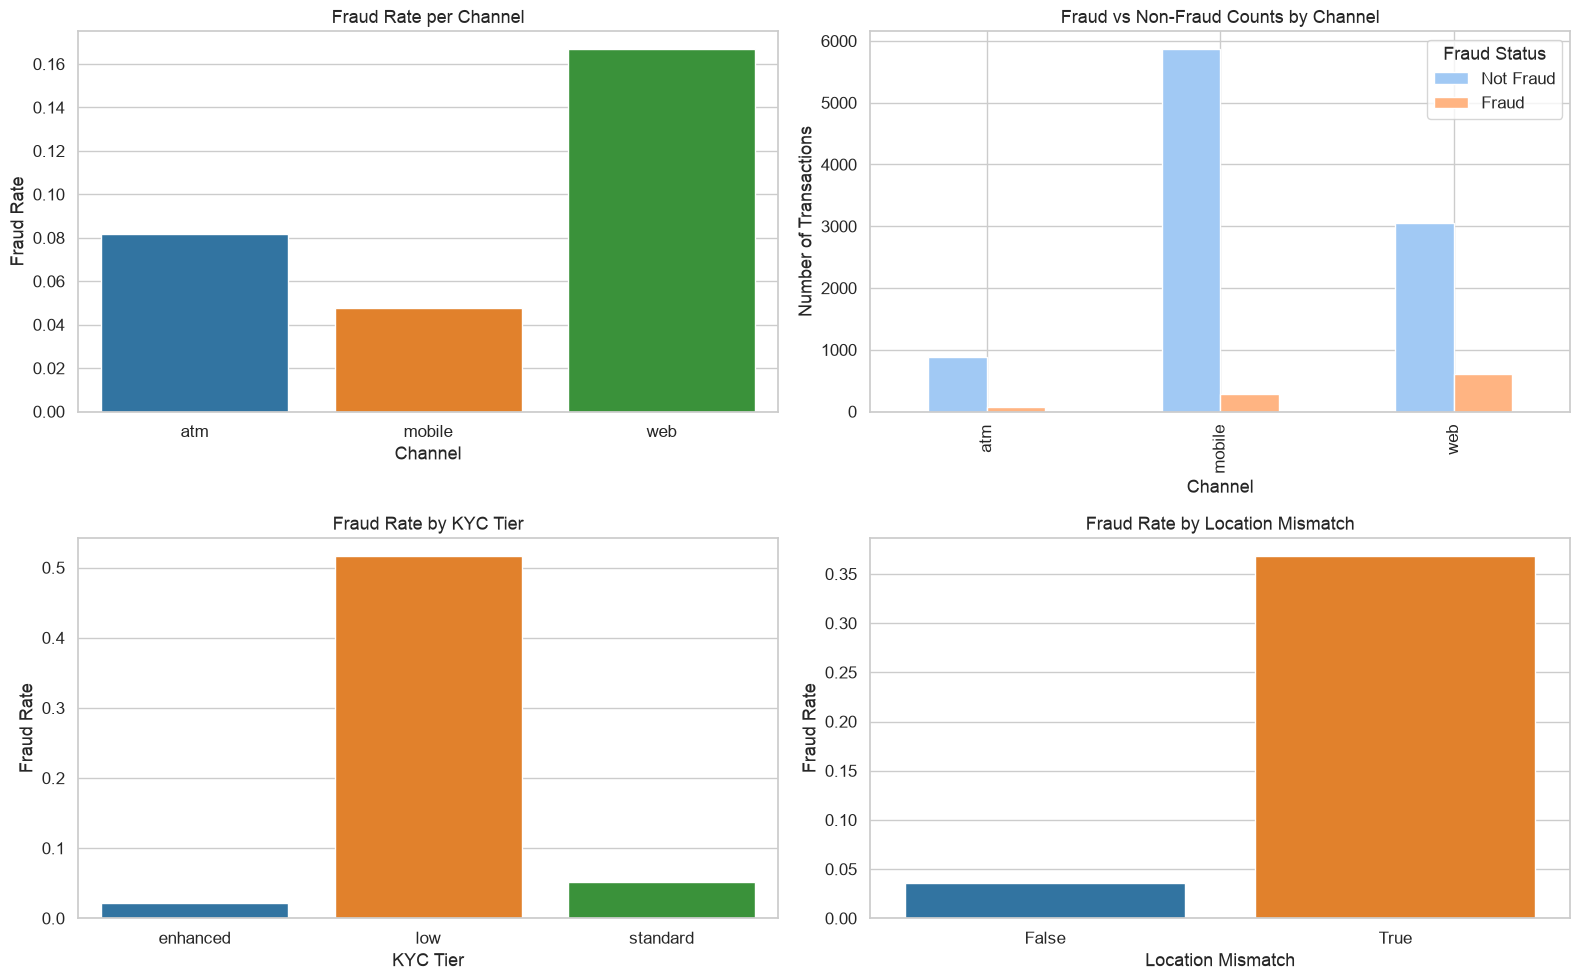

In [40]:
fig, axes = plt. subplots(2, 2, figsize= (16, 10))

# 1. Fraud rate per channel
channel_fraud_rate = cleaned_customer_transaction_data.groupby('channel')['is_fraud']. mean(). reset_index()

sns.barplot(
    data=channel_fraud_rate, 
    x= 'channel', 
    y= 'is_fraud',
    ax=axes [0, 0], 
    palette='tab10'
)
axes[0, 0].set_title('Fraud Rate per Channel')
axes[0, 0].set_xlabel('Channel')
axes[0, 0].set_ylabel('Fraud Rate')

# 2. Fraud vs Non-Fraud counts per channel
channel_counts = (
    cleaned_customer_transaction_data.groupby('channel')['is_fraud']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

channel_counts = channel_counts.rename(
    columns={0: 'Not Fraud', 1: 'Fraud'}
)

channel_counts.plot(
    x='channel',
    y=['Not Fraud', 'Fraud'],
    kind='bar',
    ax=axes [0, 1]
)

axes[0, 1].set_title('Fraud vs Non-Fraud Counts by Channel') 
axes[0, 1].set_xlabel('Channel')
axes[0, 1].set_ylabel('Number of Transactions')
axes[0, 1].legend(title='Fraud Status')

# 3. Fraud rate per pYc tier
kyc_fraud_rate = cleaned_customer_transaction_data.groupby('kyc_tier')['is_fraud' ].mean().reset_index()

sns.barplot(
    data=kyc_fraud_rate,
    x='kyc_tier',
    y= 'is_fraud',
    ax=axes [1, 0], 
    palette='tab10'
)

axes[1, 0].set_title('Fraud Rate by KYC Tier') 
axes[1, 0].set_xlabel('KYC Tier')
axes[1, 0].set_ylabel('Fraud Rate')

# 4. Fraud rate per location mismatch
location_fraud_rate = (
    cleaned_customer_transaction_data.groupby("location_mismatch")['is_fraud']
    .mean()
    .reset_index()
)
sns.barplot(
        data=location_fraud_rate, 
        x="location_mismatch", 
        y="is_fraud",
        ax=axes[1, 1],
        palette="tab10"
)

axes[1, 1].set_title('Fraud Rate by Location Mismatch')
axes[1, 1].set_xlabel('Location Mismatch')
axes[1, 1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

Transaction Velocity and Fraud Risk

The charts examine the relationship between transaction velocity and the likelihood of a transaction being fraudulent over both 1-hour and 24-hour periods. The results show a strong relationship between unusually high transaction frequency and fraudulent activity in the dataset.

For 1-hour transaction velocity, accounts making only one or two transactions within an hour have a very low fraud rate, representing relatively normal transaction behaviour. However, a substantial increase occurs around the third transaction, where the fraud rate rises sharply to above 80%. The fraud rate remains particularly high between aproximately 3 and 5 transactions per hour, reaching around 70-80%. This pattern sugests that rapid bursts of transactions may be an important indicator of compromised accounts or automated fraudulent activity. Although the fraud rate begins to decline after five transactions and reaches aproximately 45% around eight transactions per hour, it remains considerably higher than the baseline.

A similar pattern can be observed for 24-hour transaction velocity. Accounts making between 0 and 3 transactions per day have an extremely low observed fraud rate. However, the fraud rate increases substantially as transaction frequency rises, reaching approximately 75% around five transactions per day. Between approximately 5 and 8 transactions, the fraud rate remains relatively high at around 70-80%, despite a slight decline around eight transactions. The rate then increases again, approaching 100% at around 10 transactions per day in the observed data.

Overall, the results sugest that transaction velocity is an important behavioural signal for fraud detection.
Higher transaction frequency, particularly when transactions occur in rapid bursts, is strongly associated fraudulent activity in this dataset. These velocity-based features (txn_velocity_1h and txn_velocity_24h) may therefore provide valuable predictive information for the machine learning models. However, the observed rates should be interpreted as dataset-specific patterns rather than universal fraud thresholds, and their importance should be validated during model training and evaluation.

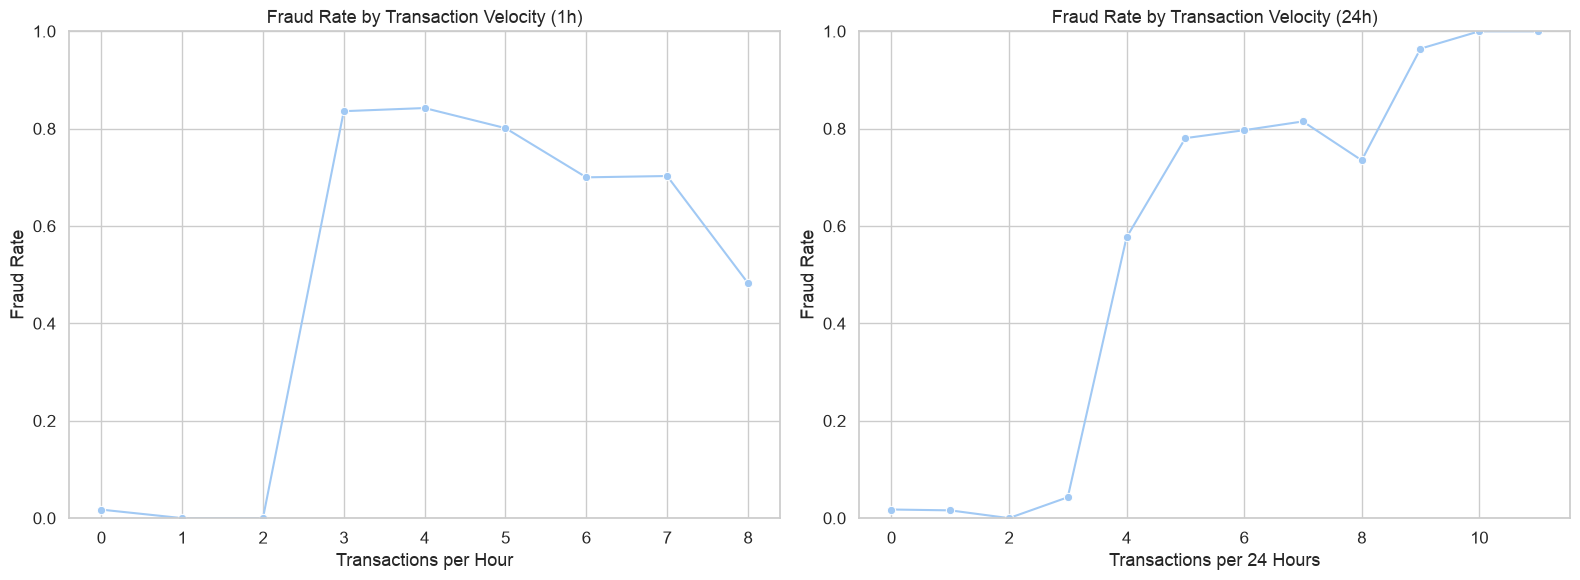

In [41]:
fig, axes = plt. subplots(1, 2, figsize=(16, 6))

# 1. Fraud rate by transaction velocity (1 hour)
txn_velocity_1h = (
    cleaned_customer_transaction_data.groupby('txn_velocity_1h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=txn_velocity_1h,
    x='txn_velocity_1h',
    y='is_fraud',
    marker='o', 
    ax=axes [0]
)
axes[0].set_title('Fraud Rate by Transaction Velocity (1h)')
axes[0].set_xlabel('Transactions per Hour')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)  # Set y-axis limits to [0, 1] for better visualization

# 2. Fraud rate by transaction velocity (24 hours)
txn_velocity_24h = (
    cleaned_customer_transaction_data.groupby('txn_velocity_24h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=txn_velocity_24h,
    x='txn_velocity_24h',
    y='is_fraud',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Fraud Rate by Transaction Velocity (24h)')
axes[1].set_xlabel('Transactions per 24 Hours')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

/var/folders/13/c_bqr3w50896v5pg8y3p6zg80000gn/T/ipykernel_9316/426486754.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


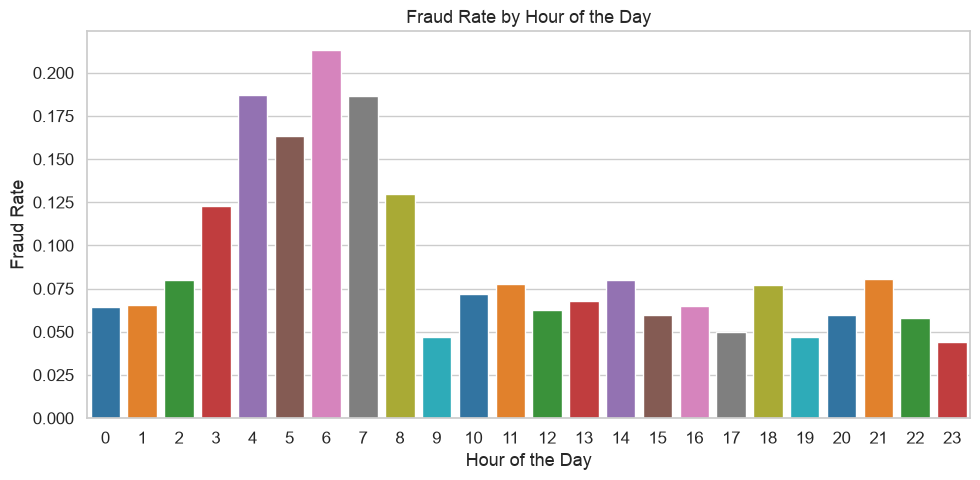

In [45]:
cleaned_customer_transaction_data['timestamp'] = pd.to_datetime(cleaned_customer_transaction_data['timestamp'])

# Extract time-based features
cleaned_customer_transaction_data['hour'] = cleaned_customer_transaction_data['timestamp'].dt.hour
cleaned_customer_transaction_data['day_of_week'] = cleaned_customer_transaction_data['timestamp'].dt.dayofweek
cleaned_customer_transaction_data['is_weekend' ] = (cleaned_customer_transaction_data['day_of_week'] >= 5).astype(int)
cleaned_customer_transaction_data['month'] = cleaned_customer_transaction_data['timestamp'].dt.month

# Fraud rate by hour
fraud_rate_by_hour = (
    cleaned_customer_transaction_data.groupby('hour')['is_fraud']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_rate_by_hour, 
    x='hour', 
    y='is_fraud', 
    palette='tab10'
)

plt.xlabel('Hour of the Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of the Day')

plt.tight_layout()
plt.show()

CREATING A NEW "ACCOUNT AGE BRACKET" COLUMN

creating a column called account age bracket. This is to know which account age group has the highest fraudulent transactions. The graph shows that new accounts created between the 1 to 90 days are the ones prone to fraud compare to the longer account, so attention needs to be paid to these new accounts to reduce fraudulant transaction rate. 

/var/folders/13/c_bqr3w50896v5pg8y3p6zg80000gn/T/ipykernel_9316/1787218851.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


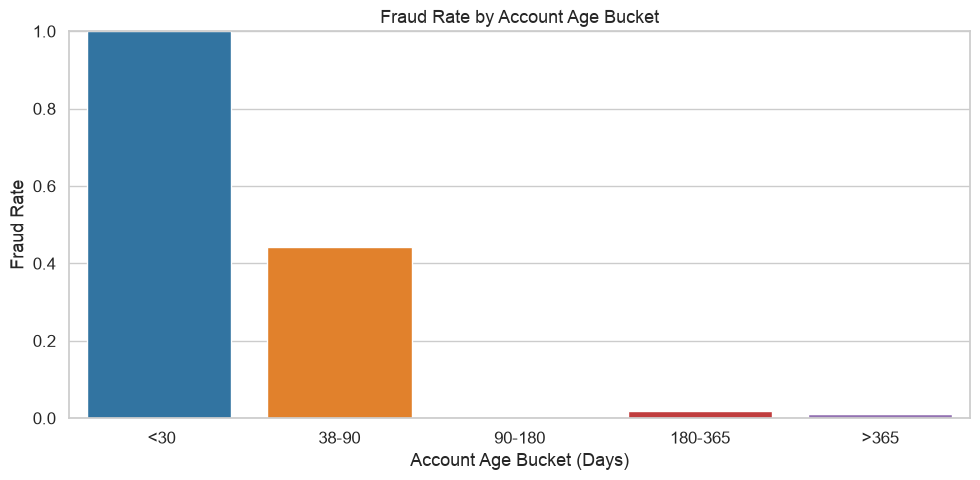

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creating account age buckets column
cleaned_customer_transaction_data['account_age_bucket'] = pd.cut(
    cleaned_customer_transaction_data ['account_age_days'], 
    bins=[8, 30, 90, 100, 365, 2000],
    labels=[' <30', '38-90', '90-180', '180-365', '>365']
)

# Calculate fraud rate by account age bucket
fraud_rate_by_account_age = (
    cleaned_customer_transaction_data.groupby('account_age_bucket', observed=True)['is_fraud']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_rate_by_account_age, 
    x='account_age_bucket', 
    y='is_fraud', 
    palette='tab10'
)

plt.xlabel('Account Age Bucket (Days)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Account Age Bucket')
plt.ylim(0, 1)  # Set y-axis limits to [0, 1] for better visualization

plt.tight_layout()
plt.show()

/var/folders/13/c_bqr3w50896v5pg8y3p6zg80000gn/T/ipykernel_9316/1188487227.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/13/c_bqr3w50896v5pg8y3p6zg80000gn/T/ipykernel_9316/1188487227.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/13/c_bqr3w50896v5pg8y3p6zg80000gn/T/ipykernel_9316/1188487227.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


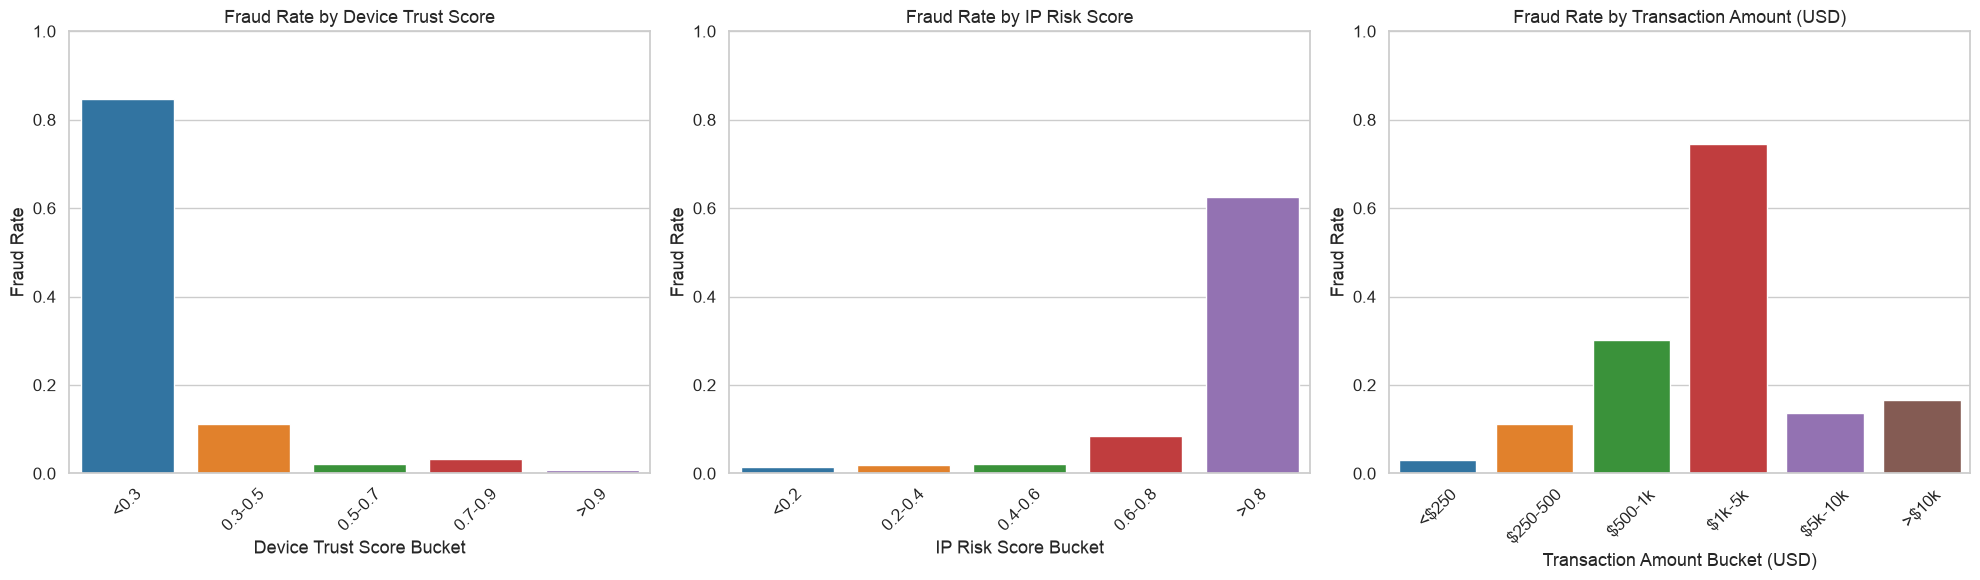

In [61]:
# Create 3 columns
fig, axes = plt.subplots(1, 3, figsize = (20, 6))

# 1. Fraud Rate by Device Trust Score

cleaned_customer_transaction_data['device_trust_score_bucket'] = pd.cut(
    cleaned_customer_transaction_data['device_trust_score'],
    bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0],
    labels=['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '>0.9'],
    include_lowest=True
)

fraud_rate_by_device_trust_score = (
    cleaned_customer_transaction_data.groupby(
        'device_trust_score_bucket', 
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_device_trust_score,
    x='device_trust_score_bucket',
    y='is_fraud',
    ax=axes [0],
    palette='tab10'
)

axes [0].set_title('Fraud Rate by Device Trust Score')
axes [0].set_xlabel('Device Trust Score Bucket')
axes [0].set_ylabel('Fraud Rate')
axes [0].set_ylim(0, 1)  # Set y-axis limits to [0, 1] for better visualization
axes [0].tick_params(axis='x', rotation=45)

# 2. Fraud Rate by IP Risk Score

cleaned_customer_transaction_data['ip_risk_score_bucket'] = pd.cut(
    cleaned_customer_transaction_data['ip_risk_score'], 
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>0.8'],
    include_lowest=True
)

fraud_rate_by_ip_risk_score = (
    cleaned_customer_transaction_data.groupby(
        'ip_risk_score_bucket',
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_ip_risk_score,
    x='ip_risk_score_bucket',
    y='is_fraud',
    ax=axes [1],
    palette='tab10'
)
axes [1].set_title('Fraud Rate by IP Risk Score')
axes [1].set_xlabel('IP Risk Score Bucket')
axes [1].set_ylabel('Fraud Rate')
axes [1].set_ylim(0, 1)  # Set y-axis limits to [0, 1] for better visualization
axes [1].tick_params(axis='x', rotation=45)

# 3. Fraud Rate by Transaction Amount

cleaned_customer_transaction_data['amount_usd_bucket'] = pd.cut(
    cleaned_customer_transaction_data['amount_usd'], 
    bins=[0, 250, 500, 1000, 5000, 10000, 20000], 
    labels=[
        '<$250',
        '$250-500', 
        '$500-1k',
        '$1k-5k',
        '$5k-10k',
        '>$10k'
    ],
    include_lowest=True
)

fraud_rate_by_amount_usd = (
    cleaned_customer_transaction_data.groupby(
        'amount_usd_bucket',
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_amount_usd,
    x='amount_usd_bucket',
    y='is_fraud',
    ax=axes[2],
    palette='tab10'
)

axes [2].set_title('Fraud Rate by Transaction Amount (USD)')
axes [2].set_xlabel('Transaction Amount Bucket (USD)')
axes [2].set_ylabel('Fraud Rate')
axes [2].set_ylim(0, 1)  # Set y-axis limits to [0, 1] for better visualization
axes [2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()